## BONUS - Scene Recognition via Deep Learning
Group Number: 14

In [52]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score
import sys
sys.path.append("../task3")
import utils

from data_loader import get_data_loaders
from model import get_scene_model
from trainer import train_model
                

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_dir = "../task3/data/scene/train"
test_dir  = "../task3/data/scene/test"

train_loader, test_loader, num_classes = get_data_loaders(train_dir, test_dir)

print("Classes:", train_loader.dataset.classes)
print("Num classes:", num_classes)


Device: cpu
Classes: ['bedroom', 'coast', 'forest', 'kitchen', 'livingroom', 'mountain', 'office', 'store', 'street', 'tallbuilding']
Num classes: 10


### 2 Transfer Learning 
Transfer learning with a pretrained ResNet18 (ImageNet weights) Residual Neural Network. The final classification layer is replaced and trained first, while the pretrained backbone is initially frozen.

In [53]:

model = get_scene_model(num_classes, device)

print("Num in features:", model.fc.in_features)
print("Num out features:", model.fc.out_features)

Num in features: 512
Num out features: 10


### 3 Optimizer & Learning Rate Scheduler
1. Criterion
Uses CrossEntropyLoss for multiclasses.

2. Optimizer
High-level optimizer Adam with Regularization: weight decay

3. LR scheduler: Step LR
Changing the learning rate depending on the current epoch or even the current step. 
A StepLR learning rate scheduler is used to reduce the learning rate by a fixed factor after a predefined number of epochs, which helps to stabilize training and improve convergence.

In [54]:
criterion = nn.CrossEntropyLoss()

# High-level optimizer Adam from PyTorch
optimizer = torch.optim.Adam(
    model.fc.parameters(), # only optimize the classifier parameters
    lr=1e-3, # learning rate
    weight_decay=1e-4 # Weight decay (L2 regularization) to prevent overfitting
    )

# Learning rate scheduler to reduce learning rate during training
scheduler = torch.optim.lr_scheduler.StepLR( #todo: change lr scheduler to lambdaLR with custom lambda function
    optimizer,
    step_size=5, # StepLR, every 5 epochs 
    gamma=0.1   # reduce lr by factor 0.1
    )

### 4 Training Loop
The training loop alternates between training and evaluation for each epoch.
The model parameters are optimized using Adam and a learning rate scheduler, and the best-performing model is saved based on validation accuracy.

In [55]:
train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs=20, device=device)

Epoch [1/20] Loss: 1.9969 Train Acc: 31.31% Test Acc: 50.00% LR: 0.001000
New best model saved with accuracy 50.00
Epoch [2/20] Loss: 1.4375 Train Acc: 54.00% Test Acc: 63.00% LR: 0.001000
New best model saved with accuracy 63.00
Epoch [3/20] Loss: 1.2376 Train Acc: 60.31% Test Acc: 66.75% LR: 0.001000
New best model saved with accuracy 66.75
Epoch [4/20] Loss: 1.1276 Train Acc: 62.94% Test Acc: 67.75% LR: 0.001000
New best model saved with accuracy 67.75
Epoch [5/20] Loss: 1.0280 Train Acc: 67.38% Test Acc: 69.00% LR: 0.000100
New best model saved with accuracy 69.00
Epoch [6/20] Loss: 0.9650 Train Acc: 68.31% Test Acc: 71.25% LR: 0.000100
New best model saved with accuracy 71.25
Epoch [7/20] Loss: 0.9706 Train Acc: 69.06% Test Acc: 70.00% LR: 0.000100
Epoch [8/20] Loss: 0.9537 Train Acc: 69.00% Test Acc: 70.75% LR: 0.000100
Epoch [9/20] Loss: 1.0023 Train Acc: 68.69% Test Acc: 72.25% LR: 0.000100
New best model saved with accuracy 72.25
Epoch [10/20] Loss: 0.9525 Train Acc: 70.50% Te

### 5 Evaluation & Documentation
1. Calculate suitable metrics (e.g., accuracy) 
2. Plot Confusion Matrix
3. Compare to Bovw approach

Compared to the Bag-of-Visual-Words approach from Task 3, the ResNet18-based model used in the bonus task achieves a clearly higher test accuracy.
While the BoVW models reach about 43 % (and around 50 % for the improved variant), the CNN model achieves a test accuracy of around 72 %.
The confusion matrix shows that outdoor scene classes such as coast, forest, mountain and street are classified very reliably.
Most remaining errors occur between visually and semantically similar indoor classes like bedroom, livingroom and kitchen, which is expected.
Overall, the deep learning–based approach performs significantly better than the handcrafted feature methods used in Task 3.

Model loaded from best_model.pth
Test Accuracy: 72.25%


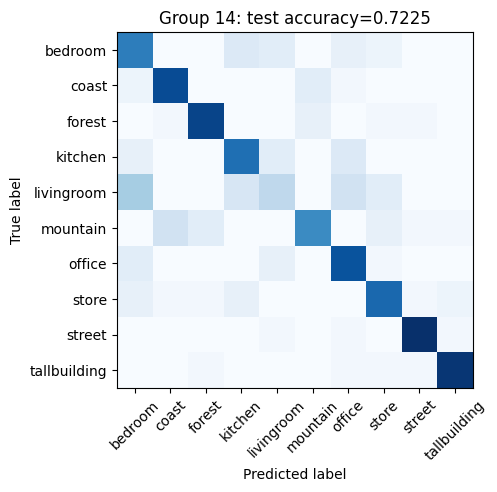

Confusion matrix saved to results/bonus_confusion_matrix_resnet18.png


In [56]:
# Load the best model
best_path = "best_model.pth"

model.load_state_dict(torch.load(best_path, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded from", best_path)

# Predicions & Accuracy
gt_labels = []
predicted = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        predicted.extend(preds.tolist())
        gt_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(gt_labels, predicted)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

utils.plot_confusion_matrix(
    gt_labels=gt_labels,
    predicted=predicted,
    accuracy=accuracy,
    class_names=train_loader.dataset.classes,
    group_no="Group 14",
    name="bonus_confusion_matrix_resnet18.png"
)

print("Confusion matrix saved to results/bonus_confusion_matrix_resnet18.png")